In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
load_dotenv()

True

In [10]:
class CricketState(TypedDict, total=False):
    runs: int
    balls: int
    fours: int
    sixes: int
    st_rate:float
    boundry_perc: float
    balls_per_boundary: float
    summary: str

In [16]:
def cal_strike_rate(state: CricketState):
    sr_rate = (state['runs'] / state['balls']) * 100

    return {
        'st_rate': sr_rate
    }


def cal_boundary_perc(state: CricketState):
    boundary_perc = (
        ((state['fours'] * 4) + (state['sixes'] * 6))
        / state['runs']
    ) * 100

    return {
        'boundry_perc': boundary_perc
    }


def cal_bpb(state: CricketState):
    balls_per_boundary = (
        state['balls'] /
        (state['fours'] + state['sixes'])
    )

    return {
        'balls_per_boundary': balls_per_boundary
    }


def generate_summary(state: CricketState):
    summary = f"""
Strike rate - {state['st_rate']}

Balls per boundary - {state['balls_per_boundary']}

Boundary percentage - {state['boundry_perc']}
"""

    return {
        'summary': summary
    }

In [17]:
graph = StateGraph(CricketState)

# nodes
graph.add_node('cal_strike_rate', cal_strike_rate)
graph.add_node('cal_boundary_perc', cal_boundary_perc)
graph.add_node('cal_bpb', cal_bpb)
graph.add_node('generate_summary', generate_summary)

# edges
graph.add_edge(START, 'cal_strike_rate')
graph.add_edge(START, 'cal_boundary_perc')
graph.add_edge(START, 'cal_bpb')

graph.add_edge('cal_strike_rate', 'generate_summary')
graph.add_edge('cal_boundary_perc', 'generate_summary')
graph.add_edge('cal_bpb', 'generate_summary')

graph.add_edge('generate_summary', END)

# compile graph
workflow = graph.compile()

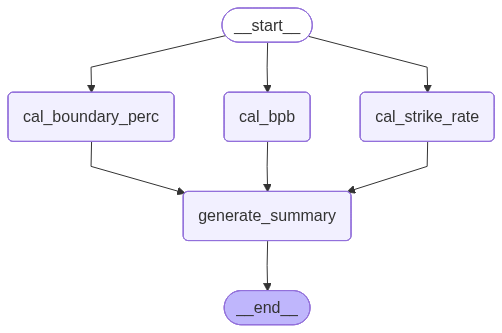

In [18]:
workflow

In [19]:
initial_state = {'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'st_rate': 200.0, 'boundry_perc': 48.0, 'balls_per_boundary': 5.0, 'summary': '\nStrike rate - 200.0\n\nBalls per boundary - 5.0\n\nBoundary percentage - 48.0\n'}
